In [17]:
#!pip install datasets pandas numpy seaborn matplotlib tensorflow scikit-learn collections
from datasets import load_dataset
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from datasets import load_dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.layers import TextVectorization, Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.models import Sequential
from collections import Counter

In [18]:
ds = load_dataset("armanc/pubmed-rct20k")
print(ds)

Repo card metadata block was not found. Setting CardData to empty.


DatasetDict({
    train: Dataset({
        features: ['abstract_id', 'label', 'text', 'sentence_id'],
        num_rows: 176642
    })
    validation: Dataset({
        features: ['abstract_id', 'label', 'text', 'sentence_id'],
        num_rows: 29672
    })
    test: Dataset({
        features: ['abstract_id', 'label', 'text', 'sentence_id'],
        num_rows: 29578
    })
})


In [19]:
df_train = pd.DataFrame(ds['train'])
df_train.head()

,abstract_id,label,text,sentence_id
0,24293578,objective,To investigate the efficacy of @ weeks of dail...,0
1,24293578,methods,A total of @ patients with primary knee OA wer...,1
2,24293578,methods,Outcome measures included pain reduction and i...,2
3,24293578,methods,Pain was assessed using the visual analog pain...,3
4,24293578,methods,Secondary outcome measures included the Wester...,4


In [20]:
df_validation = pd.DataFrame(ds['validation'])
df_validation.head()

,abstract_id,label,text,sentence_id
0,24290286,background,IgE sensitization to Aspergillus fumigatus and...,0
1,24290286,background,It is not clear whether these patients would b...,1
2,24290286,objective,We sought to determine whether a @-month cours...,2
3,24290286,methods,Asthmatic patients who were IgE sensitized to ...,3
4,24290286,methods,Primary outcomes were improvement in quality o...,4


In [21]:
df_test = pd.DataFrame(ds['test'])
df_test.head()

,abstract_id,label,text,sentence_id
0,24845963,background,This study analyzed liver function abnormaliti...,0
1,24845963,results,A post hoc analysis was conducted with the use...,1
2,24845963,results,Liver function tests ( LFTs ) were measured at...,2
3,24845963,results,Survival analyses were used to assess the asso...,3
4,24845963,results,The percentage of patients with abnormal LFTs ...,4


In [22]:
label_counts = df_train['label'].value_counts()
label_props = df_train['label'].value_counts(normalize=True) * 100
print(label_counts)
print(label_props.round(2))

label
methods        59281
results        57953
conclusions    27168
background     18402
objective      13838
Name: count, dtype: int64
label
methods        33.56
results        32.81
conclusions    15.38
background     10.42
objective       7.83
Name: proportion, dtype: float64


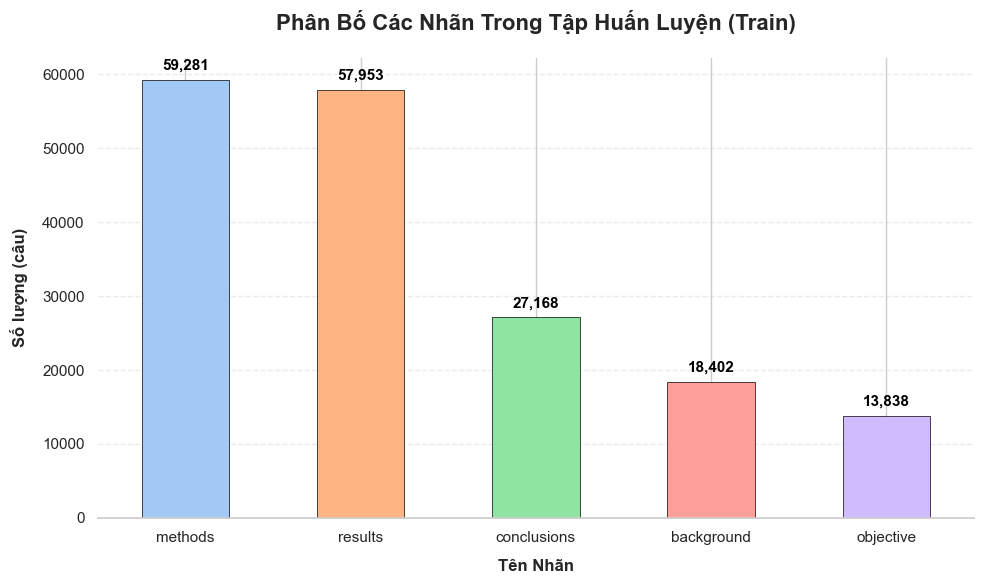

In [23]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

colors = sns.color_palette("pastel", len(label_counts))

ax = label_counts.plot(kind='bar', color=colors, edgecolor='black', linewidth=0.5)

plt.title('Phân Bố Các Nhãn Trong Tập Huấn Luyện (Train)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tên Nhãn', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Số lượng (câu)', fontsize=12, fontweight='bold', labelpad=10)

plt.xticks(rotation=0, fontsize=11, fontweight='500')
plt.yticks(fontsize=11)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.grid(axis='y', linestyle='--', alpha=0.4)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=11, color='black', fontweight='bold',
                xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

In [24]:
df_train['sentence_len'] = df_train['text'].apply(lambda x: len(x.split()))
print(f"Câu ngắn nhất: {df_train['sentence_len'].min()} từ")
print(f"Câu dài nhất: {df_train['sentence_len'].max()} từ")
print(f"Độ dài trung bình: {df_train['sentence_len'].mean():.1f} từ")

Câu ngắn nhất: 1 từ
Câu dài nhất: 296 từ
Độ dài trung bình: 26.7 từ


In [25]:
mu = df_train['sentence_len'].mean()

sigma = df_train['sentence_len'].std()

max_len_math = mu + 2 * sigma

print(f"--- THỐNG KÊ CHI TIẾT TẬP DỮ LIỆU ---")
print(f"Trung bình (μ): {mu:.2f} từ/câu")
print(f"Độ lệch chuẩn (σ): {sigma:.2f} từ")
print(f"-----------------------------------")
print(f"=> Điểm cắt theo công thức (μ + 2σ) = {int(max_len_math)} từ")

--- THỐNG KÊ CHI TIẾT TẬP DỮ LIỆU ---
Trung bình (μ): 26.70 từ/câu
Độ lệch chuẩn (σ): 15.28 từ
-----------------------------------
=> Điểm cắt theo công thức (μ + 2σ) = 57 từ


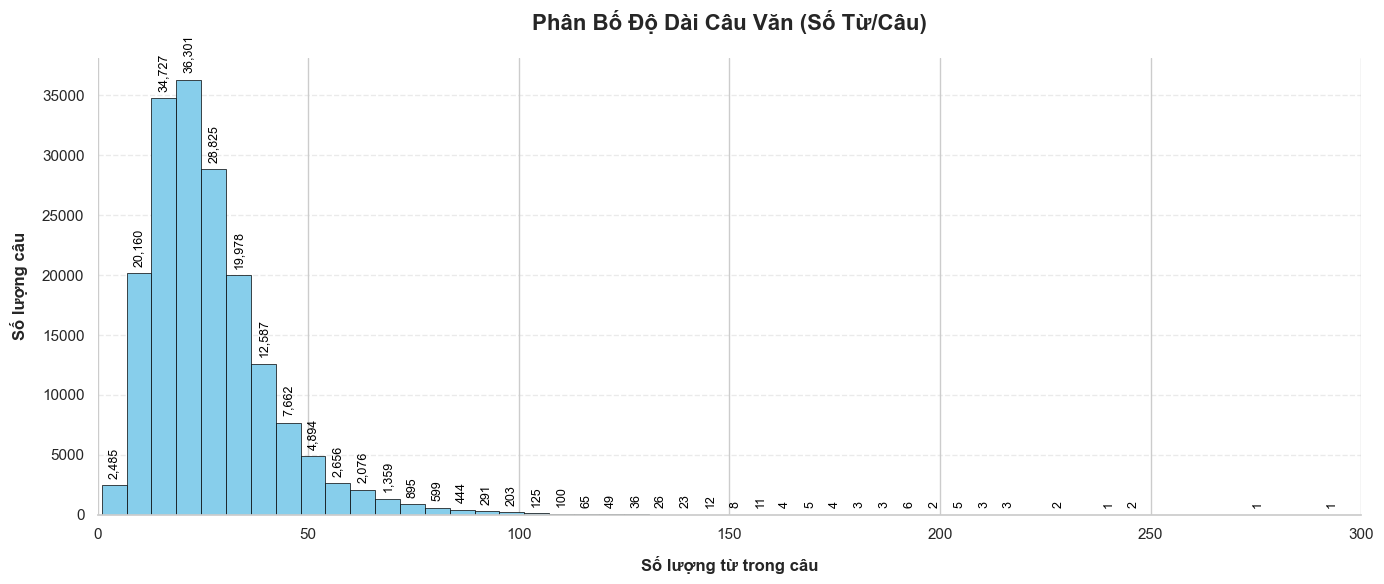

In [26]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 6))

counts, bins, patches = plt.hist(df_train['sentence_len'], bins=50,
                                 color='skyblue', edgecolor='black', linewidth=0.5)

plt.title('Phân Bố Độ Dài Câu Văn (Số Từ/Câu)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Số lượng từ trong câu', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Số lượng câu', fontsize=12, fontweight='bold', labelpad=10)

plt.xlim(0, 300)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.grid(axis='y', linestyle='--', alpha=0.4)

y_padding = max(counts) * 0.015

for count, patch in zip(counts, patches):
    if count > 0:
        plt.text(x=patch.get_x() + patch.get_width() / 2,
                 y=patch.get_height() + y_padding,
                 s=f'{int(count):,}',
                 ha='center', va='bottom',
                 fontsize=9, color='black', rotation=90) 

plt.tight_layout()
plt.show()

In [27]:
p90 = df_train['sentence_len'].quantile(0.90)
p95 = df_train['sentence_len'].quantile(0.95)
p99 = df_train['sentence_len'].quantile(0.99)

print(f"90% số câu trong dữ liệu dài dưới {p90} từ.")
print(f"95% số câu trong dữ liệu dài dưới {p95} từ.")
print(f"99% số câu trong dữ liệu dài dưới {p99} từ.")

90% số câu trong dữ liệu dài dưới 45.0 từ.
95% số câu trong dữ liệu dài dưới 55.0 từ.
99% số câu trong dữ liệu dài dưới 80.0 từ.


C:\Users\DELL\AppData\Local\Temp\ipykernel_22352\2175752826.py:25: UserWarning: Glyph 7889 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 7889 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


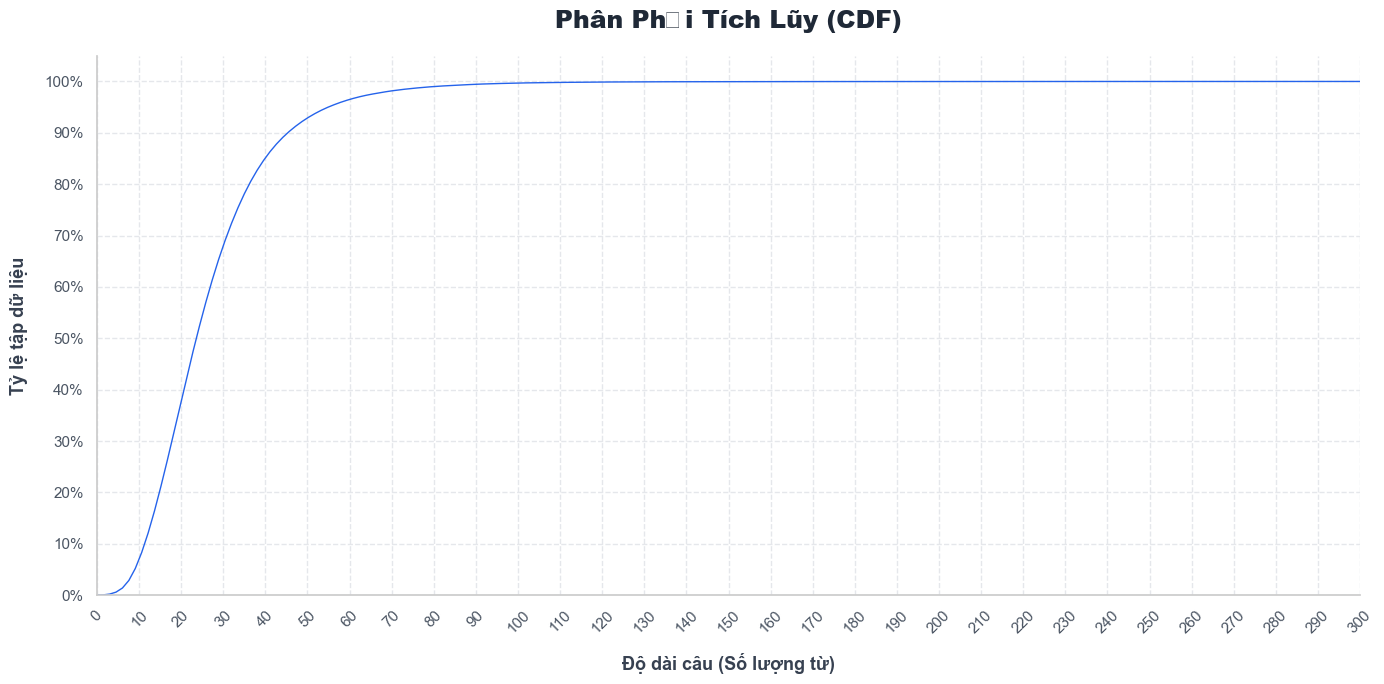

In [28]:
sns.set_theme(style="whitegrid", rc={
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": "#E5E7EB",
    "grid.linestyle": "--"
})
plt.figure(figsize=(14, 7))

sns.kdeplot(data=df_train, x='sentence_len', cumulative=True, color='#2563EB', linewidth=1)

plt.title('Phân Phối Tích Lũy (CDF)', fontsize=18, fontweight='900', pad=20, color='#1F2937')
plt.xlabel('Độ dài câu (Số lượng từ)', fontsize=13, fontweight='bold', labelpad=12, color='#374151')
plt.ylabel('Tỷ lệ tập dữ liệu', fontsize=13, fontweight='bold', labelpad=12, color='#374151')

y_ticks = np.arange(0, 1.1, 0.1)
y_labels = [f"{int(val*100)}%" for val in y_ticks] 
plt.yticks(y_ticks, y_labels, fontsize=11, color='#4B5563')

x_ticks = np.arange(0, 301, 10)
plt.xticks(x_ticks, rotation=45, fontsize=11, color='#4B5563')

plt.xlim(0, 300)
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_22352\516886481.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top_words, x='Tần suất', y='Từ vựng', palette='viridis')


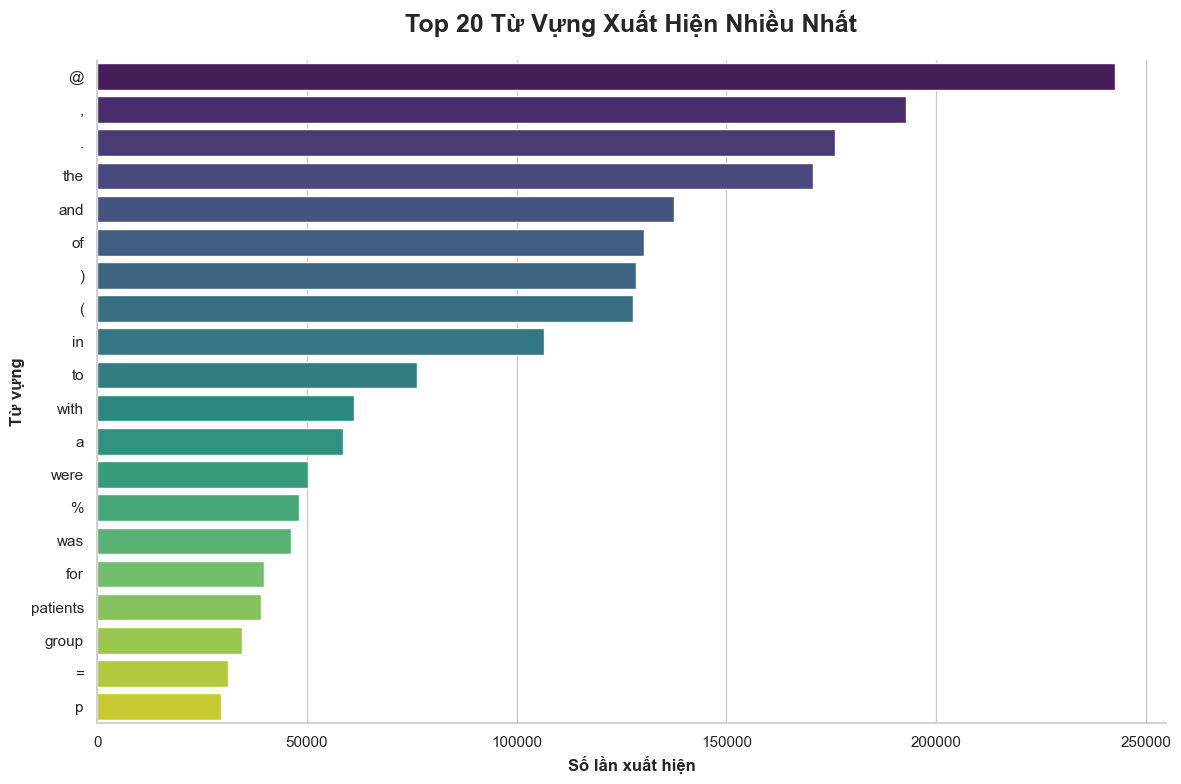

In [29]:
all_text = " ".join(df_train['text'].astype(str).tolist()).lower()
words = all_text.split()

word_counts = Counter(words)

top_20_words = word_counts.most_common(20)

df_top_words = pd.DataFrame(top_20_words, columns=['Từ vựng', 'Tần suất'])

sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})
plt.figure(figsize=(12, 8))

sns.barplot(data=df_top_words, x='Tần suất', y='Từ vựng', palette='viridis')

plt.title('Top 20 Từ Vựng Xuất Hiện Nhiều Nhất', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Số lần xuất hiện', fontsize=12, fontweight='bold')
plt.ylabel('Từ vựng', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()